# Effective Medium Approximation Across a Partially Graded Interface

This example compares a sharp, unmixed interface with graded effective-medium layers. The fractions for the graded layers come from `utils_graded_layers.get_mixing_ratios`, and the effective permittivity is calculated with `utils_effective_medium.get_graded_effective_medium`.

We use two materials from the built-in database, `SiO2` and `TiO2`, and plot the complex relative permittivity as a function of depth at one wavelength. The total stack shown here is thicker than the graded region, so pure material remains on both sides of the mixed interface.

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxlayerlumos import utils_effective_medium
from jaxlayerlumos import utils_materials
from jaxlayerlumos import utils_graded_layers

## Select Materials, Wavelength, and Depth Model

The effective-medium utility expects frequency in Hz, consistent with the rest of JaxLayerLumos. The total displayed thickness is 300 nm, while only the central 100 nm is graded. The outer regions remain unmixed.

In [2]:
material1 = "SiO2"
material2 = "TiO2"

wavelength_nm = 550.0
frequency_hz = 299_792_458.0 / (wavelength_nm * 1e-9)
frequencies = jnp.array([frequency_hz])

num_graded_layers = 25
total_thickness_nm = 300.0
graded_thickness_nm = 100.0
ema_methods = ["linear", "Maxwell-Garnett", "Bruggeman"]

half_total_nm = total_thickness_nm / 2
half_graded_nm = graded_thickness_nm / 2
left_pure_region = (-half_total_nm, -half_graded_nm)
graded_region = (-half_graded_nm, half_graded_nm)
right_pure_region = (half_graded_nm, half_total_nm)

print(f"Materials: {material1} -> {material2}")
print(f"Wavelength: {wavelength_nm:.1f} nm")
print(f"Total thickness: {total_thickness_nm:.1f} nm")
print(f"Graded thickness: {graded_thickness_nm:.1f} nm")
print(f"Graded layers: {num_graded_layers}")

Materials: SiO2 -> TiO2
Wavelength: 550.0 nm
Total thickness: 300.0 nm
Graded thickness: 100.0 nm
Graded layers: 25


## Build the Unmixed and Mixed Profiles

The unmixed profile is a sharp step from material 1 to material 2 at depth 0. The mixed profiles keep pure material 1 on the left, pure material 2 on the right, and replace only the central interface region with intermediate EMA layers.

`get_mixing_ratios` returns the material-2 fraction, so `f1 = 1 - f2` for a transition from material 1 to material 2.

In [3]:
n_k = utils_materials.get_n_k([material1, material2], frequencies)
eps_materials, _ = utils_materials.convert_n_k_to_eps_mu_for_non_magnetic_materials(n_k)
eps1 = np.asarray(eps_materials[0, 0])
eps2 = np.asarray(eps_materials[0, 1])

# Sharp interface across the full displayed thickness.
depth_step_nm = np.array([-half_total_nm, 0.0, 0.0, half_total_nm])
eps_step = np.array([eps1, eps1, eps2, eps2])

# EMA layer centers only occupy the central graded region.
ratios_material2 = utils_graded_layers.get_mixing_ratios(num_graded_layers)
layer_centers_nm = np.linspace(
    -half_graded_nm,
    half_graded_nm,
    num_graded_layers + 2,
)[1:-1]

profiles = {}
for method in ema_methods:
    eps_eff, _ = utils_effective_medium.get_graded_effective_medium(
        material1,
        material2,
        frequencies,
        num_graded_layers=num_graded_layers,
        method=method,
        graded_method="linear",
    )
    eps_profile = np.asarray(eps_eff[0])
    profiles[method] = {
        "depth_nm": np.concatenate(
            [[-half_total_nm, -half_graded_nm], layer_centers_nm, [half_graded_nm, half_total_nm]]
        ),
        "epsilon": np.concatenate([[eps1, eps1], eps_profile, [eps2, eps2]]),
    }

print("First three material-2 fractions:", np.asarray(ratios_material2[:3]))
print("Last three material-2 fractions:", np.asarray(ratios_material2[-3:]))
print(f"epsilon({material1}) = {eps1:.4g}")
print(f"epsilon({material2}) = {eps2:.4g}")

First three material-2 fractions: [0.03846154 0.07692308 0.11538462]
Last three material-2 fractions: [0.88461538 0.92307692 0.96153846]
epsilon(SiO2) = 2.15-0.005642j
epsilon(TiO2) = 5.933-2.628e-07j


## Plot epsilon Versus Depth

The dashed black line is the unmixed, piecewise profile across the full thickness. Colored lines show the same full thickness with pure plateaus on each side and an EMA transition only inside the central graded region.

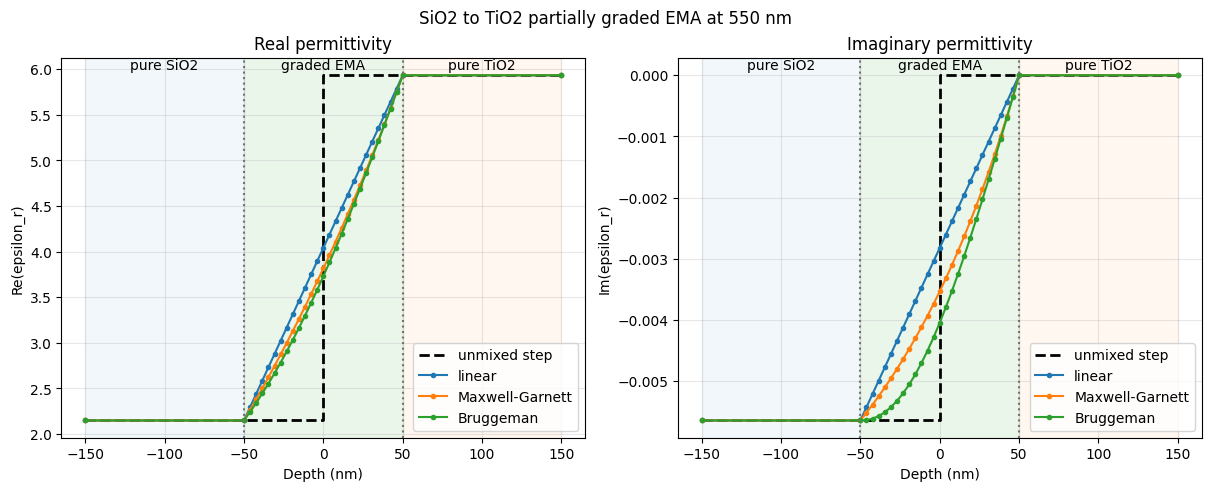

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

axes[0].plot(depth_step_nm, eps_step.real, "k--", linewidth=2, label="unmixed step")
axes[1].plot(depth_step_nm, eps_step.imag, "k--", linewidth=2, label="unmixed step")

for method, profile in profiles.items():
    depth_nm = profile["depth_nm"]
    eps_profile = profile["epsilon"]
    axes[0].plot(depth_nm, eps_profile.real, marker="o", markersize=3, label=method)
    axes[1].plot(depth_nm, eps_profile.imag, marker="o", markersize=3, label=method)

for ax in axes:
    ax.axvspan(*left_pure_region, color="tab:blue", alpha=0.06)
    ax.axvspan(*graded_region, color="tab:green", alpha=0.09)
    ax.axvspan(*right_pure_region, color="tab:orange", alpha=0.06)
    ax.axvline(-half_graded_nm, color="0.45", linestyle=":", linewidth=1.5)
    ax.axvline(half_graded_nm, color="0.45", linestyle=":", linewidth=1.5)
    ax.text(-100, ax.get_ylim()[1], f"pure {material1}", ha="center", va="top")
    ax.text(0, ax.get_ylim()[1], "graded EMA", ha="center", va="top")
    ax.text(100, ax.get_ylim()[1], f"pure {material2}", ha="center", va="top")
    ax.set_xlabel("Depth (nm)")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_title("Real permittivity")
axes[0].set_ylabel("Re(epsilon_r)")
axes[1].set_title("Imaginary permittivity")
axes[1].set_ylabel("Im(epsilon_r)")

fig.suptitle(f"{material1} to {material2} partially graded EMA at {wavelength_nm:.0f} nm")
plt.show()

## Try Another Fraction Profile

The EMA method and the fraction profile are independent choices. This cell keeps the Bruggeman EMA formula and compares linear, sine, and exponential graded fractions while preserving the pure material regions.

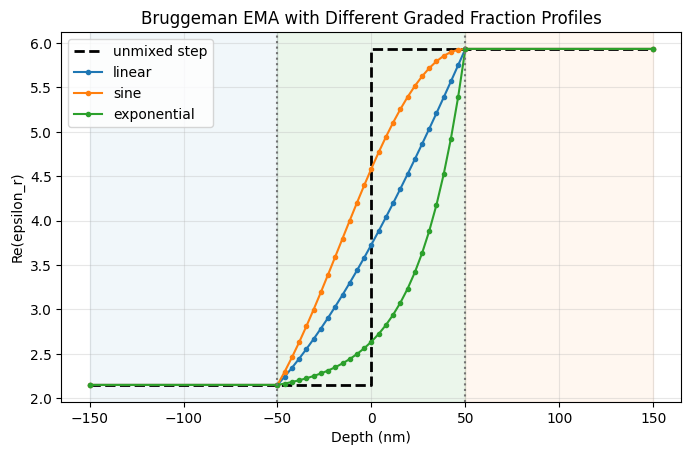

In [5]:
graded_methods = ["linear", "sine", "exponential"]

plt.figure(figsize=(8, 4.8))
plt.plot(depth_step_nm, eps_step.real, "k--", linewidth=2, label="unmixed step")

for graded_method in graded_methods:
    eps_eff, _ = utils_effective_medium.get_graded_effective_medium(
        material1,
        material2,
        frequencies,
        num_graded_layers=num_graded_layers,
        method="Bruggeman",
        graded_method=graded_method,
        beta=3.0,
    )
    eps_profile = np.asarray(eps_eff[0])
    depth_profile_nm = np.concatenate(
        [[-half_total_nm, -half_graded_nm], layer_centers_nm, [half_graded_nm, half_total_nm]]
    )
    eps_profile_with_plateaus = np.concatenate([[eps1, eps1], eps_profile, [eps2, eps2]])
    plt.plot(depth_profile_nm, eps_profile_with_plateaus.real, marker="o", markersize=3, label=graded_method)

plt.axvspan(*left_pure_region, color="tab:blue", alpha=0.06)
plt.axvspan(*graded_region, color="tab:green", alpha=0.09)
plt.axvspan(*right_pure_region, color="tab:orange", alpha=0.06)
plt.axvline(-half_graded_nm, color="0.45", linestyle=":", linewidth=1.5)
plt.axvline(half_graded_nm, color="0.45", linestyle=":", linewidth=1.5)
plt.title("Bruggeman EMA with Different Graded Fraction Profiles")
plt.xlabel("Depth (nm)")
plt.ylabel("Re(epsilon_r)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()